In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [17]:
df=pd.read_csv('data.csv')

In [18]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [19]:
df.isna().sum().sum()

np.int64(0)

In [25]:
y=df['target']
X=df.drop('target',axis=1)

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [27]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [28]:
y_pred=lr.predict(X_test)

In [29]:
#####  Checking multi-collinearity  #####

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train,i))

In [31]:
pd.DataFrame({'vif':vif},index=df.columns[0:3])

,vif
feature1,1.007179
feature2,1.016725
feature3,1.019546


In [32]:
df.corr()

,feature1,feature2,feature3,target
feature1,1.000000,-0.001055,0.049286,0.818926
feature2,-0.001055,1.000000,0.060387,0.031267
feature3,0.049286,0.060387,1.000000,0.578142
target,0.818926,0.031267,0.578142,1.000000


In [35]:
### Normal Residual ##
###error that is come after plotting the best fit line
residual=y_test-y_pred

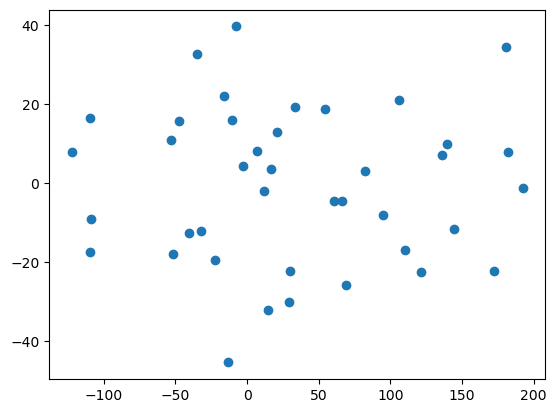

In [36]:

### homoscedasticty  ###
plt.scatter(y_pred,residual)

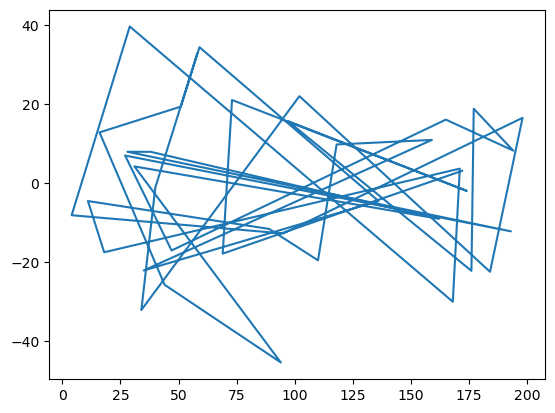

In [38]:
#### No autocorrelation of error #####
plt.plot(residual)